In [1]:
#creating a directory
!mkdir ~/.kaggle

The syntax of the command is incorrect.


In [2]:

#importing libraries for model evaluation and algorithms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.metrics import roc_curve,auc
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")
#import nltk
#nltk.data.path.append('C:\\Users\\Ria\\AppData\\Roaming\\nltk_data')
#from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import  MultinomialNB
import re
#from nltk.corpus import stopwords
#from nltk.stem import PorterStemmer
#from nltk.stem.wordnet import WordNetLemmatizer

In [3]:
#nltk.download('punkt', force=True)

In [4]:
#nltk.download('stopwords', force=True)

In [5]:
#nltk.download('wordnet', force=True)
#nltk.download('averaged_perceptron_tagger')

# Now I am going to create a second model which takes into account only positive and negative tweets

In [6]:
#reading the dataframe
data=pd.read_csv('Tweets.csv')
print(data.columns)
data.head()

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [7]:
# removing neutral sentiments
data = data[data['airline_sentiment'] != 'neutral']

# reset index
data.reset_index(inplace=True, drop=True)

# convert labels: positive = 1, negative = 0
def partition(x):
    if x == 'positive':
        return 1
    return 0

actualSentiment = data['airline_sentiment']
positiveNegative = actualSentiment.map(partition)

data['Sentiment'] = positiveNegative

data['Sentiment'].value_counts()

Sentiment
0    9178
1    2363
Name: count, dtype: int64

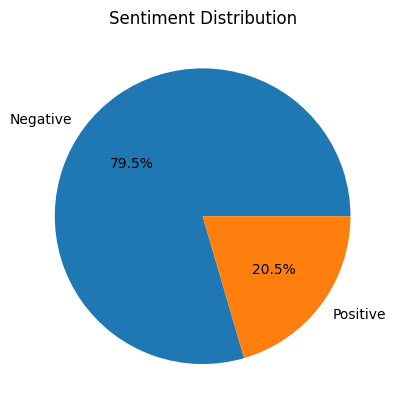

In [8]:
import matplotlib.pyplot as plt

sentiment_counts = data['Sentiment'].value_counts()

labels = ['Negative', 'Positive']
sizes = [sentiment_counts[0], sentiment_counts[1]]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

In [9]:
#tweets conssits of every document as an array of tokenized words which are later appended to docs 
tweets=[tweet.split() for tweet in data['text']]
docs=[]
for j in range(0,len(tweets)):
    docs.append(tweets[j])

In [10]:
#stops includes both the stopwords and punctuations
from nltk.corpus import stopwords
import string
stops = set(stopwords.words('english'))
punctuations = list(string.punctuation)
stops.update(punctuations)

In [11]:
#to get the simple pos(part of speech) tag
from nltk.corpus import wordnet
def get_simple_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [12]:
#to get the pos tag for a word

# now we are going to clean our data 
# we will remove stopwords and punctuations and lemmatize each document


def clean(words):
    output = []
    for word in words:
        if word.lower() not in stops:
            output.append(word.lower())
    return " ".join(output)
docs=[ clean(doc) for doc in docs]      

In [13]:
#let's look at how our texts look after cleaning and position-tag lemmatization
docs[:5]

['@virginamerica plus added commercials experience... tacky.',
 '@virginamerica really aggressive blast obnoxious "entertainment" guests\' faces &amp; little recourse',
 '@virginamerica really big bad thing',
 '@virginamerica seriously would pay $30 flight seats playing. really bad thing flying va',
 '@virginamerica yes, nearly every time fly vx “ear worm” won’t go away :)']

In [14]:
data['text'][:5]

0    @VirginAmerica plus you've added commercials t...
1    @VirginAmerica it's really aggressive to blast...
2    @VirginAmerica and it's a really big bad thing...
3    @VirginAmerica seriously would pay $30 a fligh...
4    @VirginAmerica yes, nearly every time I fly VX...
Name: text, dtype: object

In [15]:
#training involves our clean text as independent varaible and the predicted sentiments as the dependent variable 
X = np.array(docs)
Y = np.array(data['Sentiment'])
# splitting into train-test-validation set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.33, random_state=0)
X_tr, X_cv, Y_tr, Y_cv = train_test_split(X_train, Y_train, test_size=.2, random_state=0)

In [16]:
#looking at the shapes of each of the training, test and validation sets 
print('X_train, Y_train', X_train.shape, Y_train.shape)
print('X_test, Y_test', X_test.shape, Y_test.shape)
print('X_tr, Y_tr', X_tr.shape, Y_tr.shape)
print('X_cv, Y_cv', X_cv.shape, Y_cv.shape)

X_train, Y_train (7732,) (7732,)
X_test, Y_test (3809,) (3809,)
X_tr, Y_tr (6185,) (6185,)
X_cv, Y_cv (1547,) (1547,)


In [17]:
#uses training and cross validation sets for hyperparamter tuning
def mulnb(X_train,X_cv,Y_train,Y_cv):
    best_alpha=0
    max_roc_auc=-1
    #appending auc scores of cross validation and training set in the below arrays respectively
    pred_cv = []
    pred_train = []
    alpha=[100,50,10,5,1,0.5,0.1,0.05,0.01,0.005] 
    for i in alpha[-10:]:
        mulbnb = MultinomialNB(alpha=i)
        mulbnb.fit(X_train,Y_train)
        probs = mulbnb.predict_proba(X_cv)
        prob = mulbnb.predict_proba(X_train)
        probs = probs[:,1]
        prob = prob[:,1]
        auc_score_cv = roc_auc_score(Y_cv,probs)
        auc_score_train = roc_auc_score(Y_train,prob)
        print(i," ------> ",auc_score_cv)
        pred_cv.append(auc_score_cv)
        pred_train.append(auc_score_train)
        if(max_roc_auc<auc_score_cv):
            max_roc_auc=auc_score_cv
            best_alpha=i
    print(f"\n Best alpha Value {best_alpha} with highest roc_auc Score is {max_roc_auc}")
    sns.set_style("darkgrid")
    plt.xscale('log')
    plt.plot(alpha, pred_cv,'r-', label = 'CV Data')
    plt.plot(alpha,pred_train,'g-', label ='Train Data')
    plt.legend(loc='upper right')
    plt.title(r'Auc Score v/s $\alpha$')
    plt.xlabel(r"alpha values",fontsize=12)
    plt.ylabel("roc_auc",fontsize=12)
    plt.show()
    # calculate roc curve
    fpr, tpr, thresholds = roc_curve(Y_cv,probs)
    # plot no skill
    plt.plot([0, 1], [0, 1], linestyle='--')
    # plot the roc curve for the model
    plt.plot(fpr, tpr, marker='.')
    #plt.plot(k,pred_cv)
    plt.title("Line Plot of ROC Curve on Train Data")
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()


In [18]:
#The below two lists are created to store auc and f1 scores respectively for all the vectorizations we are going to use 
AUC,F1=[],[]
def testing(X_train,Y_train,X_test,Y_test,optimal_alpha):
    bnb = MultinomialNB(alpha=optimal_alpha, fit_prior=True)
    bnb.fit(X_train,Y_train)
    probs = bnb.predict_proba(X_test) 
    # keep probabilities for the positive outcome only
    probs = probs[:, 1]
    print("AUC Score",roc_auc_score(Y_test,probs))
    AUC.append(round(roc_auc_score(Y_test,probs),2))
    # calculate roc curve
    fpr, tpr, thresholds = roc_curve(Y_test,probs)
    # plot no skill
    plt.plot([0, 1], [0, 1], linestyle='--')
    # plot the roc curve for the model
    plt.plot(fpr, tpr, marker='.')
    plt.title("Line Plot of ROC Curve on Test Data")
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')    
    plt.show()
    prediction=bnb.predict(X_test)
    cm=confusion_matrix(Y_test,prediction)
    cm1 = pd.DataFrame(cm , index = ['positive','negative'] , columns = ['positive','negative'])
    plt.figure(figsize = (10,10))
    ax=sns.heatmap(cm1,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='')
    ax.set(xlabel="Actual Sentiment", ylabel = "Predicted Sentiment")
    #printing f1 score and hamming loss
    print("f1 score for data :",metrics.f1_score(Y_test, prediction))
    F1.append(round(metrics.f1_score(Y_test, prediction),2))
    print("hamming loss for data:",metrics.hamming_loss(Y_test,prediction))
    print("Precision recall report for data:\n",metrics.classification_report(Y_test, prediction))

In [19]:
#Bag Of Words Vectorization with unigrams and bigrams
count_vect = CountVectorizer(ngram_range=(1,2)) #in scikit-learn
# In below line we get a Bag of Word model that has cleaned the text, removing non-aphanumeric characters and stop words by the fitting part and 
# a matrix where each row represents a specific text in corpus and each column represents a word in vocabulary, that is, all words found in corpus
#from the transform
bow= count_vect.fit(X_tr)
bow_train = bow.transform(X_tr)
sum_words = bow_train.sum(axis=0) 
words_freq = [(word, sum_words[0, idx]) for word, idx in bow.vocabulary_.items()]
words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
print("Top 20 words with their frequencies in training set are",words_freq[:20])
print("The type of count vectorizer ",type(bow_train))
print("The shape of out text BOW vectorizer ",bow_train.get_shape())
#print("the number of unique words ", final_counts.get_shape()[1])
bow_cv = count_vect.transform(X_cv)
bow_test = count_vect.transform(X_test)
print("CV Data Size: ",bow_cv.shape)
print("Test Data Size: ",bow_test.shape)

Top 20 words with their frequencies in training set are [('united', np.int64(1846)), ('flight', np.int64(1751)), ('usairways', np.int64(1385)), ('americanair', np.int64(1288)), ('southwestair', np.int64(984)), ('jetblue', np.int64(904)), ('get', np.int64(578)), ('cancelled', np.int64(517)), ('service', np.int64(509)), ('thanks', np.int64(506)), ('customer', np.int64(418)), ('help', np.int64(376)), ('time', np.int64(355)), ('hours', np.int64(348)), ('co', np.int64(338)), ('amp', np.int64(329)), ('plane', np.int64(324)), ('hold', np.int64(322)), ('customer service', np.int64(319)), ('http', np.int64(318))]
The type of count vectorizer  <class 'scipy.sparse._csr.csr_matrix'>
The shape of out text BOW vectorizer  (6185, 55433)
CV Data Size:  (1547, 55433)
Test Data Size:  (3809, 55433)


In [20]:
#Normalize bow data for effective model training
from sklearn import preprocessing
from sklearn.preprocessing import Normalizer
bow_train=preprocessing.normalize(bow_train)
bow_cv=preprocessing.normalize(bow_cv)
bow_test=preprocessing.normalize(bow_test)
print("The shape of out text BOW vectorizer ",bow_train.get_shape())
print("CV Data Size: ",bow_cv.shape)
print("Test Data Size: ",bow_test.shape)

The shape of out text BOW vectorizer  (6185, 55433)
CV Data Size:  (1547, 55433)
Test Data Size:  (3809, 55433)


100  ------>  0.7981466559226431
50  ------>  0.8150816598463184
10  ------>  0.8516956070636689
5  ------>  0.8668109736508088
1  ------>  0.9018212173400115
0.5  ------>  0.9161176154587539
0.1  ------>  0.9384614979486288
0.05  ------>  0.9411896372838686
0.01  ------>  0.9373818289066902
0.005  ------>  0.9339242546333602

 Best alpha Value 0.05 with highest roc_auc Score is 0.9411896372838686


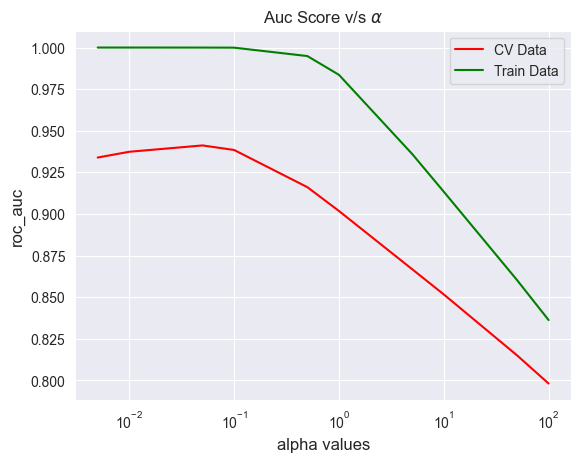

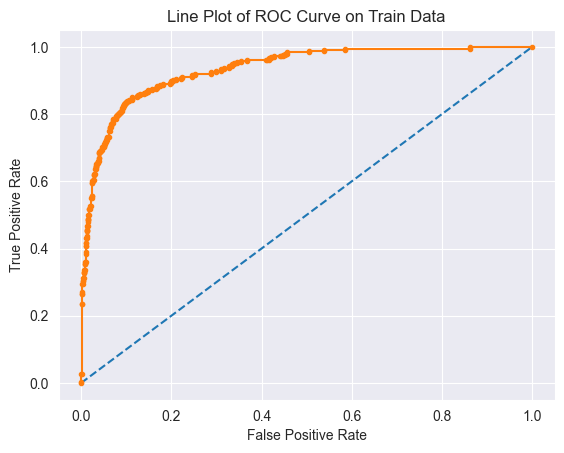

In [21]:
# find optimal value of alpha for count vectorization
mulnb(bow_train,bow_cv,Y_tr,Y_cv)

AUC Score 0.9534001713283926


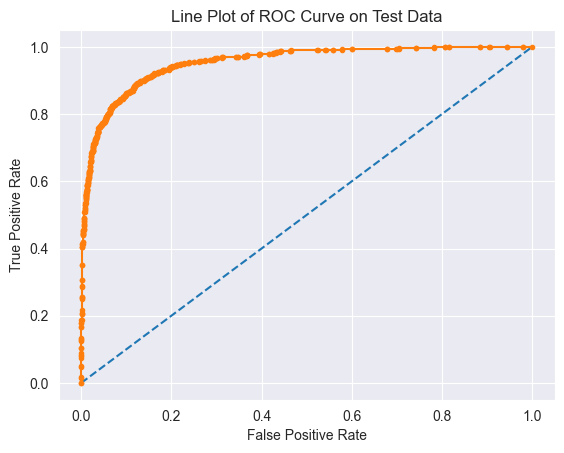

f1 score for data : 0.7073359073359073
hamming loss for data: 0.09950118141244421
Precision recall report for data:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      3008
           1       0.93      0.57      0.71       801

    accuracy                           0.90      3809
   macro avg       0.91      0.78      0.82      3809
weighted avg       0.90      0.90      0.89      3809



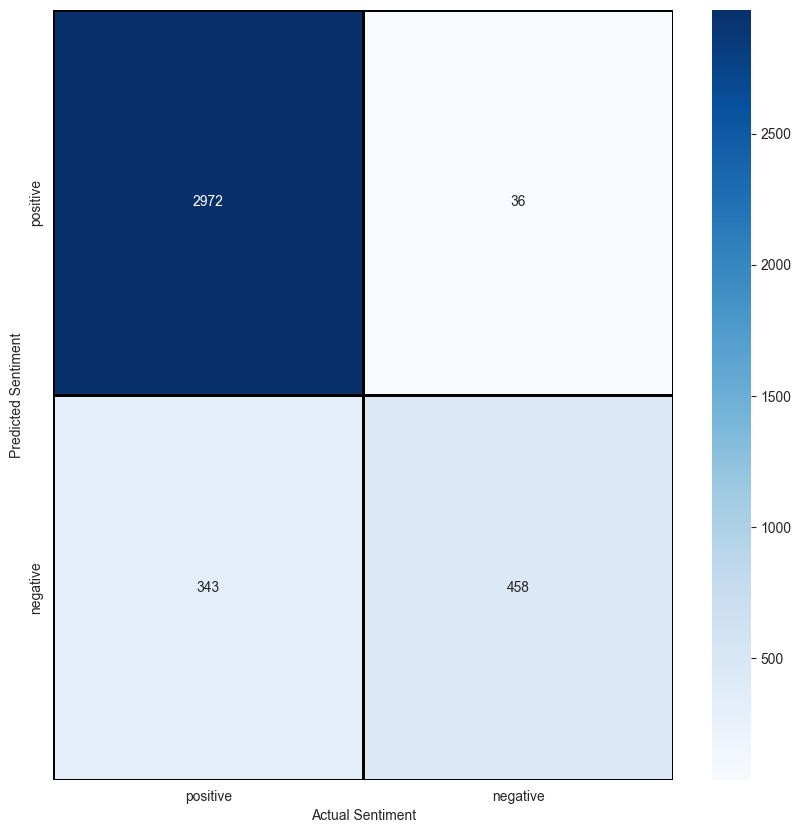

In [22]:
#optimal_alpha=0.05
testing(bow_train,Y_tr,bow_test,Y_test,optimal_alpha=0.05)

In [23]:
#TF-IDF Vectorization with unigrams and bigrams
tf_idf_vect = TfidfVectorizer(ngram_range=(1,2))
tfidf_train = tf_idf_vect.fit_transform(X_tr)
features = tf_idf_vect.get_feature_names_out()
print("some sample features(unique words in the corpus)",features[10000:10010])                                                              
print("The type of count vectorizer ",type(tfidf_train))
print("The shape of out text TFIDF vectorizer ",tfidf_train.get_shape())
tfidf_cv = tf_idf_vect.transform(X_cv)
tfidf_test = tf_idf_vect.transform(X_test)
print("CV Data Size: ",tfidf_cv.shape)
print("Test Data Size: ",tfidf_test.shape)

some sample features(unique words in the corpus) ['cars buy' 'carseat' 'carseat return' 'cart' 'cart meet' 'cart min'
 'cart one' 'cart pulls' 'cart rude' 'carta']
The type of count vectorizer  <class 'scipy.sparse._csr.csr_matrix'>
The shape of out text TFIDF vectorizer  (6185, 55433)
CV Data Size:  (1547, 55433)
Test Data Size:  (3809, 55433)


In [24]:
import pickle
pickle.dump(tf_idf_vect,open('transform.pkl','wb'))
#from google.colab import files
#files.download('transform.pkl')

In [25]:
#displaying top 25 tfidf features
def top_tfidf_feats(row, features, top_n=25):
    topn_ids = np.argsort(row)[::-1][:top_n]
    top_feats = [(features[i], row[i]) for i in topn_ids]
    
    temp_df = pd.DataFrame(top_feats, columns=['feature', 'tfidf'])
    
    return temp_df

top_tfidf = top_tfidf_feats(tfidf_train[1,:].toarray()[0],features,10)
top_tfidf

,feature,tfidf
0,miles added,0.271755
1,like miles,0.271755
2,reimbursement something,0.271755
3,asked reimbursement,0.271755
4,added account,0.271755
5,account told,0.259562
6,usairways asked,0.250911
7,something like,0.250911
8,reimbursement,0.244201
9,told call,0.223357


In [26]:
#Normalize Data for effective model training
from sklearn import preprocessing
from sklearn.preprocessing import Normalizer
tfidf_train=preprocessing.normalize(tfidf_train)
tfidf_cv=preprocessing.normalize(tfidf_cv)
tfidf_test=preprocessing.normalize(tfidf_test)
print("The shape of out text BOW vectorizer ",tfidf_train.get_shape())
print("CV Data Size: ",tfidf_cv.shape)
print("Test Data Size: ",tfidf_test.shape)

The shape of out text BOW vectorizer  (6185, 55433)
CV Data Size:  (1547, 55433)
Test Data Size:  (3809, 55433)


100  ------>  0.8354452713129302
50  ------>  0.8413702843479588
10  ------>  0.8642619013761831
5  ------>  0.8768439957234573
1  ------>  0.9088100993822186
0.5  ------>  0.9215765274683605
0.1  ------>  0.936554960420913
0.05  ------>  0.9360546259868437
0.01  ------>  0.9271460397212873
0.005  ------>  0.9223638958672375

 Best alpha Value 0.1 with highest roc_auc Score is 0.936554960420913


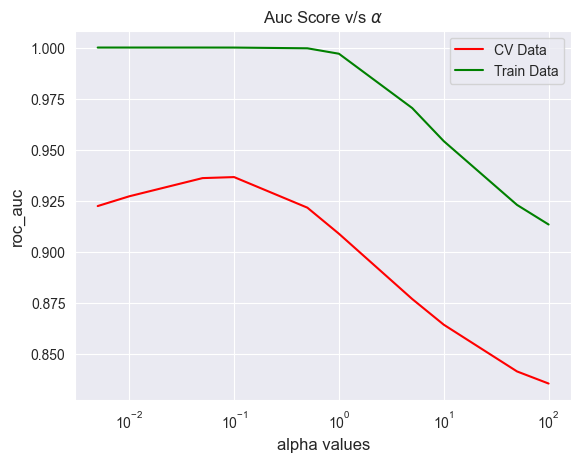

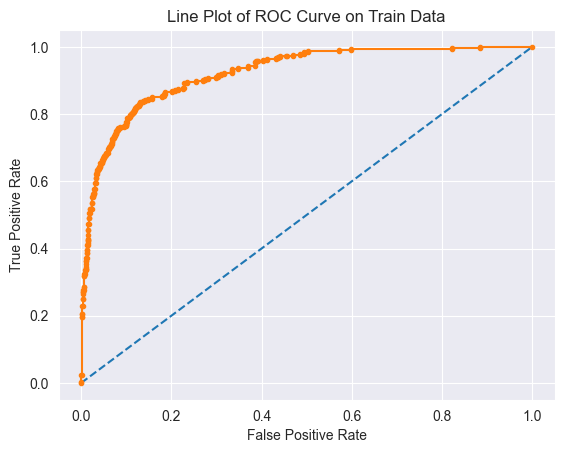

In [27]:
# find optimal_alpha for tfidf vectorization
mulnb(tfidf_train,tfidf_cv,Y_tr,Y_cv)

AUC Score 0.9502392288894201


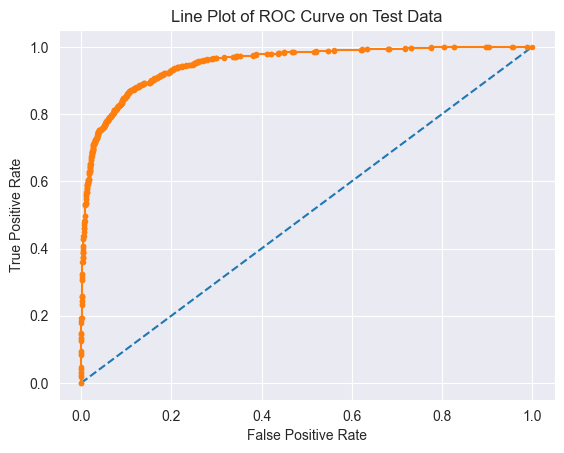

f1 score for data : 0.6762589928057554
hamming loss for data: 0.10632711997899712
Precision recall report for data:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94      3008
           1       0.94      0.53      0.68       801

    accuracy                           0.89      3809
   macro avg       0.91      0.76      0.81      3809
weighted avg       0.90      0.89      0.88      3809



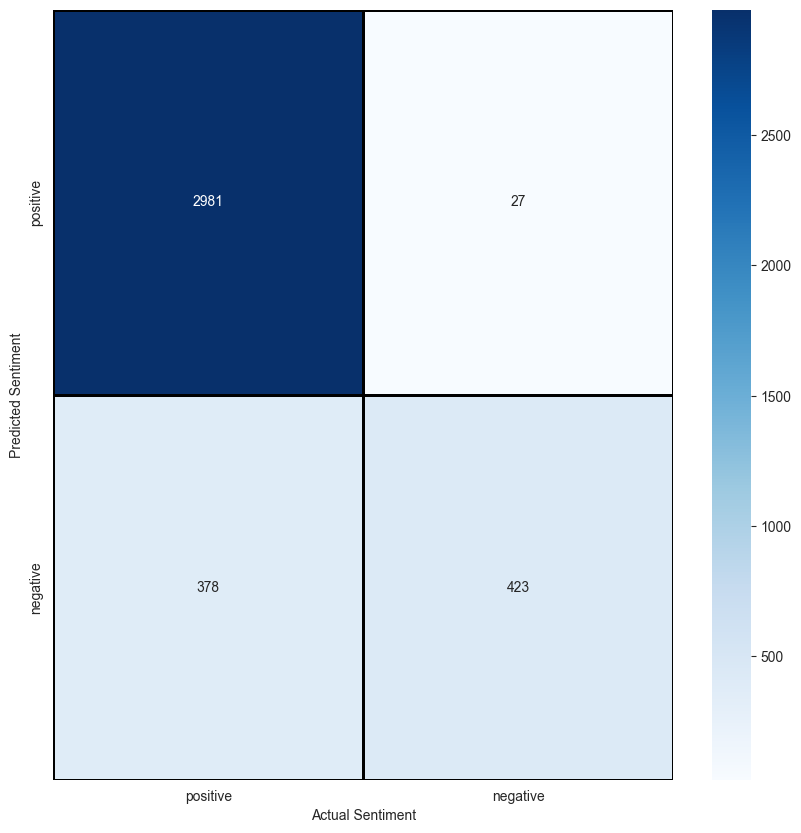

In [28]:
#using optimal alpha=0.1 for testing
testing(tfidf_train,Y_tr,tfidf_test,Y_test,optimal_alpha=0.1)

In [29]:
# removing neutral sentiments
data = data[data['airline_sentiment'] != 'neutral']

# reset index
data.reset_index(inplace=True, drop=True)

# convert labels: positive = 1, negative = 0
def partition(x):
    if x == 'positive':
        return 1
    return 0

actualSentiment = data['airline_sentiment']
positiveNegative = actualSentiment.map(partition)

data['Sentiment'] = positiveNegative

data['Sentiment'].value_counts()

Sentiment
0    9178
1    2363
Name: count, dtype: int64

In [30]:
#Here I have displayed how the Multinomial Naive Bayes performed for both BOW and TF-IDF Vectorization
from IPython.display import display
 # intialise data of lists.
results_data = {'Category':['BOW Vectorization','TF-IDF Vectorization'],
        'AUC Score':AUC,
        'F1-Score':F1}
results_df = pd.DataFrame(results_data)
 
# Print the output.
display(results_df)      

,Category,AUC Score,F1-Score
0,BOW Vectorization,0.95,0.71
1,TF-IDF Vectorization,0.95,0.68


In [31]:
print(data.columns)

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone', 'Sentiment'],
      dtype='object')


In [32]:
bnb = MultinomialNB()

X = tf_idf_vect.transform(data['text'])
y = data['Sentiment']

# splitting into train-test-validation set
from imblearn.combine import SMOTETomek
smtom = SMOTETomek(random_state=100)

X_smtom, y_smtom = smtom.fit_resample(X, y)

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_smtom, y_smtom, test_size=0.2, random_state=0)

bnb.fit(X_train, Y_train)

sample_text = "The movie was awesome. Everything was good about it"
k = tf_idf_vect.transform([sample_text])

bnb.predict(k)

array([1])

In [33]:
sample_text = ('The movie was pathetic and terrible.Nothing was making any sense. Highly unacceptable.')
k=tf_idf_vect.transform([sample_text])
bnb.predict(k)

array([0])

In [34]:
pickle.dump(bnb,open('nlp_model.pkl','wb'))
#from google.colab import files
#files.download('nlp_model.pkl')